In [1]:
import sys
import os

# Add the folder and subfolder to the system path
sys.path.append(os.path.abspath(os.path.join('../../')))

# Now you can import your module
# from your_module import your_function

# Inport data from geopandas

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd 

parent_dir = "/home/biazzin/git/mimesis/data/ourdata/copernicus_ecdc/"
parent_dir = "../data/"
year = "2020"
df = pd.read_csv(parent_dir + f'albopictus_presence_absence_ecdc_world_clim_all_bio.zip')
#df_suitable = df[df['Suitable'] == 1]  # Select only the suitable records
df_suitable = df


In [3]:
import geopandas as gpd 
import fiona

zip_file_path = parent_dir + 'VectorData/mosquitoes/GeoPortal ECDC/20230828_VectorFlatFileGDB.gdb.zip'
#zip_file_path = parent_dir + 'data/mosquitoes/GeoPortal ECDC/20230828_VectorFlatFileGDB.gdb.zip'

# Add `zip://` prefix to read directly from the zipped file
zip_gdb_path = f"zip://{zip_file_path}"

# List all layers in the Geodatabase (optional step)
layers = fiona.listlayers(zip_gdb_path)
print(f"Available layers: {layers}")

# Read a specific layer from the zipped GDB file
gdf = gpd.read_file(zip_gdb_path)#, layer=layers[0])
gdf = gdf[gdf['VectorCategoryCode'] == 'Mosq']
# Convert to Pandas DataFrame (optional if you don't need geometries)
#df = gdf.drop(columns='geometry')  # Only if you want non-geospatial data
gdf.head()
code_to_status = {
    'INV001A': 'Established',
    'INV002A': 'Introduced',
    'INV003A': 'Absent',
    'INV004A': 'No data',
    'INV999A': 'Unknown',
    'NAT001A': 'Present',
    'NAT002A': 'Absent',
    'NAT003A': 'Absent',
    'NAT004A': 'No data',
    'NAT005A': 'Introduced',
    'NAT999A': 'Unknown'
}


gdf['status'] = gdf['AssessedDistributionStatus'].map(code_to_status)
species_mapping = dict(zip(gdf['VectorSpeciesCode'], gdf['VectorSpeciesName']))
gdf_NUTS3 = gdf[gdf['VectorSpeciesName'].str.contains('albo', case=False, na=False)]
gdf_NUTS3["NUTS3_Code"] = gdf_NUTS3["LocationCode"]
gdf_NUTS3.plot(column='status', legend=True)


ModuleNotFoundError: No module named 'fiona'

In [ ]:
# set presence absence to 1 if suitable is 1, otherwise set to 0
df_Presence_Absence = (df_suitable[(df_suitable["Presence_Absence"] == 1) | (df_suitable["Presence_Absence"] == 0)]).copy()

df_Presence_Absence["Presence_Absence"] = ((df_Presence_Absence['Presence_Absence'] == 1) & (df_Presence_Absence['Suitable'] == 1)).astype(int)


In [ ]:

# Get unique values from both columns
unique_nuts3_codes = set(df_Presence_Absence["NUTS3_Code"].unique())
unique_other_codes = set(gdf_NUTS3["NUTS3_Code"].unique())

# Check if all NUTS3_Code values are present in Other_Code
all_present = unique_nuts3_codes.issubset(unique_other_codes)

if all_present:
    print("All codes in df_Presence_Absence['NUTS3_Code'] are present in df_Other['Other_Code'].")
else:
    print("Some codes in df_Presence_Absence['NUTS3_Code'] are missing in df_Other['Other_Code'].")
    # Optionally, list the missing codes
    missing_codes = unique_nuts3_codes - unique_other_codes
    print("Missing codes:", missing_codes)

NameError: name 'gdf_NUTS3' is not defined

# Check data and remove points set as absence close to points set as presence

In [ ]:
import geopandas as gpd

df_gdf = gpd.GeoDataFrame(df_Presence_Absence, geometry=gpd.points_from_xy(df_Presence_Absence['Longitude'], df_Presence_Absence['Latitude']))

In [ ]:
import geopandas as gpd

# Assuming `gdf` is your GeoDataFrame with a 'record' column that indicates 'presence' or 'absence'
df_gdf.set_crs(epsg=4326, inplace=True)

df_gdf = df_gdf.to_crs(epsg=3857)

# Step 1: Split into presence and absence records
presence_gdf = df_gdf[df_gdf['Presence_Absence'] == 1]
absence_gdf = df_gdf[df_gdf['Presence_Absence'] == 0]

# Step 2: Buffer presence points by 1 km (distance in meters; assumes CRS in meters)
presence_buffered = presence_gdf.copy()
presence_buffered['geometry'] = presence_buffered.geometry.buffer(1000)  # 1 km buffer
print("Buffered presence points")
# Step 3: Spatial join to find absence points within 1 km of any presence point
near_presence = gpd.sjoin(absence_gdf, presence_buffered, how='inner', predicate='within')
print("Absence points near presence points")
# Step 4: Remove these absence points from the original GeoDataFrame
filtered_gdf = df_gdf[~df_gdf.index.isin(near_presence.index)]



Buffered presence points
Absence points near presence points


In [ ]:
# `filtered_gdf` now contains the cleaned GeoDataFrame without the close absence records
df_gdf.shape[0], filtered_gdf.shape[0]

(8144318, 8119582)

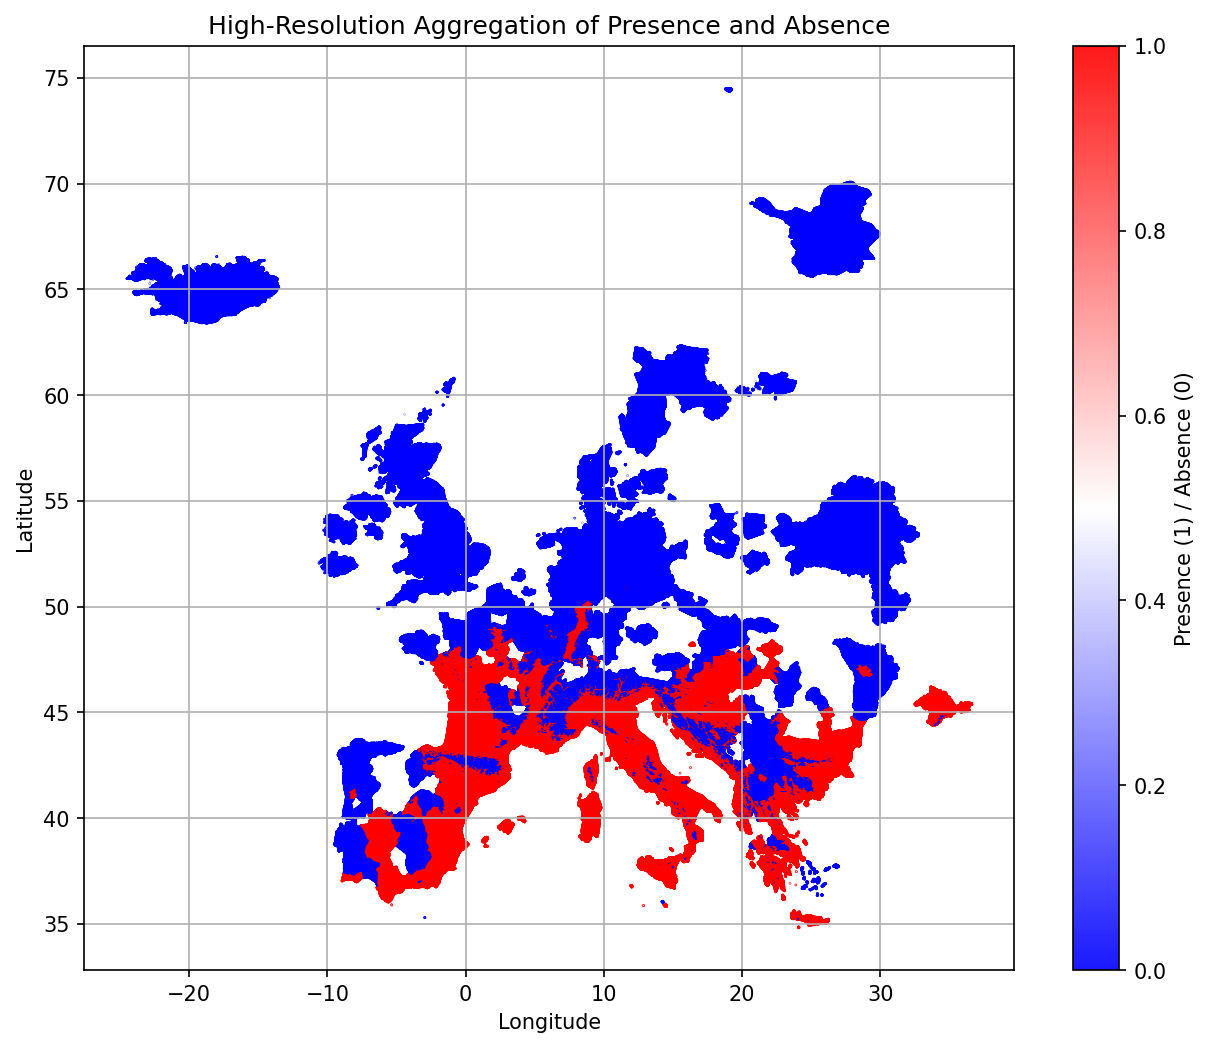

In [ ]:
import matplotlib.pyplot as plt

df_aggregated = filtered_gdf.groupby([
    filtered_gdf['Latitude'].round(4),  # Higher precision for finer grid
    filtered_gdf['Longitude'].round(4)
]).Presence_Absence.max().reset_index()

# Generate a large, high-resolution scatter plot
plt.figure(figsize=(10, 8), dpi=150)  # Large figure with high DPI for quality
plt.scatter(
    df_aggregated['Longitude'], 
    df_aggregated['Latitude'], 
    c=df_aggregated['Presence_Absence'], 
    cmap='bwr',  # Blue-White-Red, blue for absence, red for presence
    s=0.01,         # Small size for density
    alpha=0.9    # Transparency for overlapping points
)
plt.colorbar(label='Presence (1) / Absence (0)')
plt.title('High-Resolution Aggregation of Presence and Absence')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True)  # Add grid for easier geographic orientation
plt.show()


<Axes: >

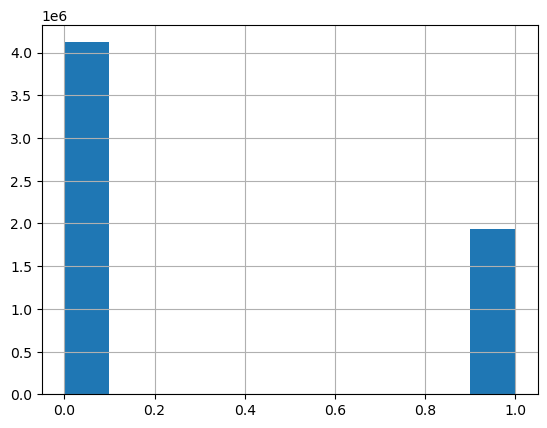

In [ ]:
df_Presence_Absence = filtered_gdf.copy()

df_Presence_Absence["Presence_Absence"].hist()

# Creting datasets

In [ ]:
features = ['annual_temp', 'annual_prec', 'max_temp_warmest_month', 'prec_warmest_quarter']
features = ['annual_temp', 'annual_prec', 'max_temp_warmest_month', 'prec_warmest_quarter', 'TAVG_01', 'TAVG_02', 'TAVG_03', 'TAVG_04', 'TAVG_05', 'TAVG_06', 'TAVG_07', 'TAVG_08', 'TAVG_09', 'TAVG_10', 'TAVG_11', 'TAVG_12']
data_four = df_Presence_Absence[features[0:4] + ["Presence_Absence"]].to_numpy()
data = df_Presence_Absence[features + ["Presence_Absence"]].to_numpy()

In [ ]:
import importlib
import src.data.data_loader
importlib.reload(src.data.data_loader)
import src.data.data_loader


ModuleNotFoundError: No module named 'src'

In [ ]:
import importlib
import src.data.data_loader
importlib.reload(src.data.data_loader)
from src.data.data_loader import get_data_loaders
# Get data loaders and input size
batch_size = 2024
learning_rate = 0.001
test_ratio = 0.2
random_seed = 42

train_loader, test_loader, input_size  = get_data_loaders(
    data=data, batch_size = batch_size, test_ratio = test_ratio, random_seed = random_seed, shuffle = True
)

train_loader_order, test_loader_order, input_size_order = get_data_loaders(
    data=data, batch_size = batch_size, test_ratio = 1, random_seed = random_seed, shuffle = False
)

train_loader_not, test_loader_not, input_size_not  = get_data_loaders(
    data=data_four, batch_size = batch_size, test_ratio = test_ratio, random_seed = random_seed, shuffle = True, normalize=False
)

train_loader_order_not, test_loader_order_not, input_size_order_not = get_data_loaders(
    data=data_four, batch_size = batch_size, test_ratio = 1, random_seed = random_seed, shuffle = False, normalize=False
)

/home/biazzin/git/mimesis/AIedes/src/data/data_loader.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.y = torch.tensor(y, dtype=torch.float)  # Labels for classification


# Function like the paper

In [ ]:
import pandas as pd
import pickle
from src.models.estim_risk import SigmaEstimRisk, EstimRisk
from src.models.fc_model import MosquitoNet
x_estim_risk = EstimRisk

with open("results_and_models.pkl", "rb") as f:
    res_df = pickle.load(f)
with open("../002_estim_risk/results_and_models.pkl", "rb") as f:
    res_df_four = pickle.load(f)



In [ ]:
import torch

def compute_suitability_index(model_, data_loader_):
    with torch.no_grad():
        res = []
        for data in data_loader_:
            inputs, labels = data
            outputs = torch.sigmoid(model_(inputs))
            res.append(outputs)
    return torch.cat(res)

In [ ]:
res_df

,accuracy_NUTS3,TPR_NUTS3,FNR_NUTS3,FPR_NUTS3,TNR_NUTS3,ACC,TPR,TNR,FPR,FNR,...,FNR_test,type,hidden_layers,num_params,bias,num_epochs,test_ratio,learning_rate,random_seed,model
0,82.743363,99.184783,0.815217,36.774194,63.225806,88.937542,0.913193,0.878175,0.121825,0.086807,...,0.086554,estim_risk,0,5,1,0,0.0,0.000,0,[<function EstimRisk at 0x7ffb965545e0>]
1,84.218289,97.282609,2.717391,31.290323,68.709677,88.958261,0.817235,0.923605,0.076395,0.182765,...,0.183422,NN,[],17,1,200,0.2,0.001,42,[MosquitoNet(\n (layers): ModuleList(\n (0...
2,85.840708,99.184783,0.815217,30.000000,70.000000,95.205363,0.933122,0.960956,0.039044,0.066878,...,0.067440,NN,[4],73,1,200,0.2,0.001,42,[MosquitoNet(\n (layers): ModuleList(\n (0...
3,84.808260,99.456522,0.543478,32.580645,67.419355,96.772999,0.962420,0.970227,0.029773,0.037580,...,0.037601,NN,[10],181,1,200,0.2,0.001,42,[MosquitoNet(\n (layers): ModuleList(\n (0...
4,85.103245,99.184783,0.815217,31.612903,68.387097,96.203685,0.947873,0.968697,0.031303,0.052127,...,0.052495,NN,"[4, 10]",129,1,200,0.2,0.001,42,[MosquitoNet(\n (layers): ModuleList(\n (0...
5,85.103245,99.728261,0.271739,32.258065,67.741935,97.674702,0.971479,0.979224,0.020776,0.028521,...,0.028683,NN,"[10, 10]",291,1,200,0.2,0.001,42,[MosquitoNet(\n (layers): ModuleList(\n (0...
6,84.808260,99.728261,0.271739,32.903226,67.096774,97.854898,0.968972,0.983053,0.016947,0.031028,...,0.030790,NN,"[10, 20]",411,1,200,0.2,0.001,42,[MosquitoNet(\n (layers): ModuleList(\n (0...
7,85.840708,100.000000,0.000000,30.967742,69.032258,98.812154,0.978536,0.992629,0.007371,0.021464,...,0.021426,NN,"[20, 20]",781,1,200,0.2,0.001,42,[MosquitoNet(\n (layers): ModuleList(\n (0...
8,86.135693,100.000000,0.000000,30.322581,69.677419,99.053310,0.986342,0.992504,0.007496,0.013658,...,0.013704,NN,"[20, 20, 20]",1201,1,200,0.2,0.001,42,[MosquitoNet(\n (layers): ModuleList(\n (0...
9,87.758112,100.000000,0.000000,26.774194,73.225806,99.270383,0.987241,0.995273,0.004727,0.012759,...,0.012873,NN,"[40, 40]",2361,1,200,0.2,0.001,42,[MosquitoNet(\n (layers): ModuleList(\n (0...


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.colors import ListedColormap
import pandas as pd
import numpy as np

def plot_results(df_, gdf_NUTS3, num_samples=10000, markersize=0.2, figsize=(20, 8), marker='.', alpha=0.8):
    """
    Plot the results of a model's predictions on a map and in a bar chart.
    """
    # Define categories and their corresponding colors
    categories = ['TP', 'TN', 'FP', 'FN']
    colors = ['#2b8cbe', '#a6bddb', '#fd8d3c', '#de2d26']
    colormap = ListedColormap(colors)
    color_dict = dict(zip(categories, colors))

    # Sample data and set the CRS
    df_sampled = df_.sample(num_samples).to_crs(epsg=3857)

    # Create 'results' column using vectorized operations
    df_sampled['results'] = np.select(
        [
            (df_sampled['Presence_Absence'] == 1) & (df_sampled['predicted'] == 1),
            (df_sampled['Presence_Absence'] == 0) & (df_sampled['predicted'] == 0),
            (df_sampled['Presence_Absence'] == 0) & (df_sampled['predicted'] == 1),
            (df_sampled['Presence_Absence'] == 1) & (df_sampled['predicted'] == 0),
        ],
        categories
    )
    df_sampled['results'] = pd.Categorical(df_sampled['results'], categories=categories)

    # Calculate percentages for the sampled data
    sampled_counts = df_sampled['results'].value_counts().reindex(categories, fill_value=0)
    total_positive = sampled_counts['TP'] + sampled_counts['FN']
    total_negative = sampled_counts['TN'] + sampled_counts['FP']
    sampled_percentages = {
        'TP': (sampled_counts['TP'] / total_positive) * 100 if total_positive > 0 else 0,
        'FN': (sampled_counts['FN'] / total_positive) * 100 if total_positive > 0 else 0,
        'TN': (sampled_counts['TN'] / total_negative) * 100 if total_negative > 0 else 0,
        'FP': (sampled_counts['FP'] / total_negative) * 100 if total_negative > 0 else 0
    }

    # Aggregate data for the second plot
    aggregated_data = df_.groupby('NUTS3_Code').agg(
        predicted=('predicted', 'max'),
        Presence_Absence=('Presence_Absence', 'max')
    ).reset_index()

    # Create 'results' column using vectorized operations
    aggregated_data['results'] = np.select(
        [
            (aggregated_data['Presence_Absence'] == 1) & (aggregated_data['predicted'] == 1),
            (aggregated_data['Presence_Absence'] == 0) & (aggregated_data['predicted'] == 0),
            (aggregated_data['Presence_Absence'] == 0) & (aggregated_data['predicted'] == 1),
            (aggregated_data['Presence_Absence'] == 1) & (aggregated_data['predicted'] == 0),
        ],
        categories
    )
    aggregated_data['results'] = pd.Categorical(aggregated_data['results'], categories=categories)

    # Merge with gdf_NUTS3 and set CRS
    merged_df = gdf_NUTS3.merge(aggregated_data[['NUTS3_Code', 'results']], on='NUTS3_Code', how='left')
    merged_df = merged_df.to_crs(epsg=3857)

    # Calculate percentages for the aggregated data
    aggregated_counts = merged_df['results'].value_counts().reindex(categories, fill_value=0)
    total_positive_agg = aggregated_counts['TP'] + aggregated_counts['FN']
    total_negative_agg = aggregated_counts['TN'] + aggregated_counts['FP']
    aggregated_percentages = {
        'TP': (aggregated_counts['TP'] / total_positive_agg) * 100 if total_positive_agg > 0 else 0,
        'FN': (aggregated_counts['FN'] / total_positive_agg) * 100 if total_positive_agg > 0 else 0,
        'TN': (aggregated_counts['TN'] / total_negative_agg) * 100 if total_negative_agg > 0 else 0,
        'FP': (aggregated_counts['FP'] / total_negative_agg) * 100 if total_negative_agg > 0 else 0
    }

    # Create the figure and axes with specified width ratios
    fig, axes = plt.subplots(1, 4, figsize=(20, 8), gridspec_kw={'width_ratios': [6, 1.5, 6, 1.5]})
    ax_map_0, ax_bar_0, ax_map_1, ax_bar_1 = axes

    # Plot the sampled data map
    df_sampled.plot(
        'results',
        markersize=markersize,
        ax=ax_map_0,
        marker=marker,
        cmap=colormap,
        legend=True,
        edgecolor='none',
        alpha=alpha
    )
    ctx.add_basemap(ax_map_0, source=ctx.providers.OpenStreetMap.Mapnik, zoom=4)
    ax_map_0.set_title('Grid Data Map')

    # Corrected code for the sampled data bar chart
    percentage_values = [sampled_percentages[cat] for cat in categories]
    x_positions = np.arange(len(categories))
    ax_bar_0.bar(x_positions, percentage_values, color=colors)
    ax_bar_0.set_title('Grid Data (%)')
    ax_bar_0.set_ylabel('Percentage')
    ax_bar_0.set_xticks(x_positions)
    ax_bar_0.set_xticklabels(categories, rotation=90)
    ax_bar_0.set_ylim(0,100)

    # Plot the aggregated data map
    merged_df.plot('results', ax=ax_map_1, cmap=colormap, legend=True)
    ctx.add_basemap(ax_map_1, source=ctx.providers.OpenStreetMap.Mapnik, zoom=4)
    ax_map_1.set_title('NUTS3 Data Map')

    # Corrected code for the aggregated data bar chart
    percentage_values_agg = [aggregated_percentages[cat] for cat in categories]
    ax_bar_1.bar(x_positions, percentage_values_agg, color=colors)
    ax_bar_1.set_title('NUTS3 Counts (%)')
    ax_bar_1.set_ylabel('Percentage')
    ax_bar_1.set_xticks(x_positions)
    ax_bar_1.set_xticklabels(categories, rotation=90)
    ax_bar_1.set_ylim(0,100)
    
    # Ensure both plots have the same axis limits
    print(ax_map_0.get_xlim())
    print(ax_map_0.get_ylim())
    # ax_map_1.set_xlim(ax_map_0.get_xlim())
    # ax_map_1.set_ylim(ax_map_0.get_ylim())
    

    x_lim = (-2e6,4e6)
    y_lim = (0.4e7,1.1e7)
    ax_map_0.set_xlim(x_lim)
    ax_map_1.set_xlim(x_lim)
    ax_map_0.set_ylim(y_lim)
    ax_map_1.set_ylim(y_lim)
    print(ax_map_0.get_xlim())
    print(ax_map_0.get_ylim())


    plt.subplots_adjust(wspace=0.0)
    plt.tight_layout()
    plt.show()

    return fig, axes

0
(-3070052.4067149945, 4418873.570160157)
(3709060.0108139873, 13155194.195017159)
(-2000000.0, 4000000.0)
(4000000.0, 11000000.0)


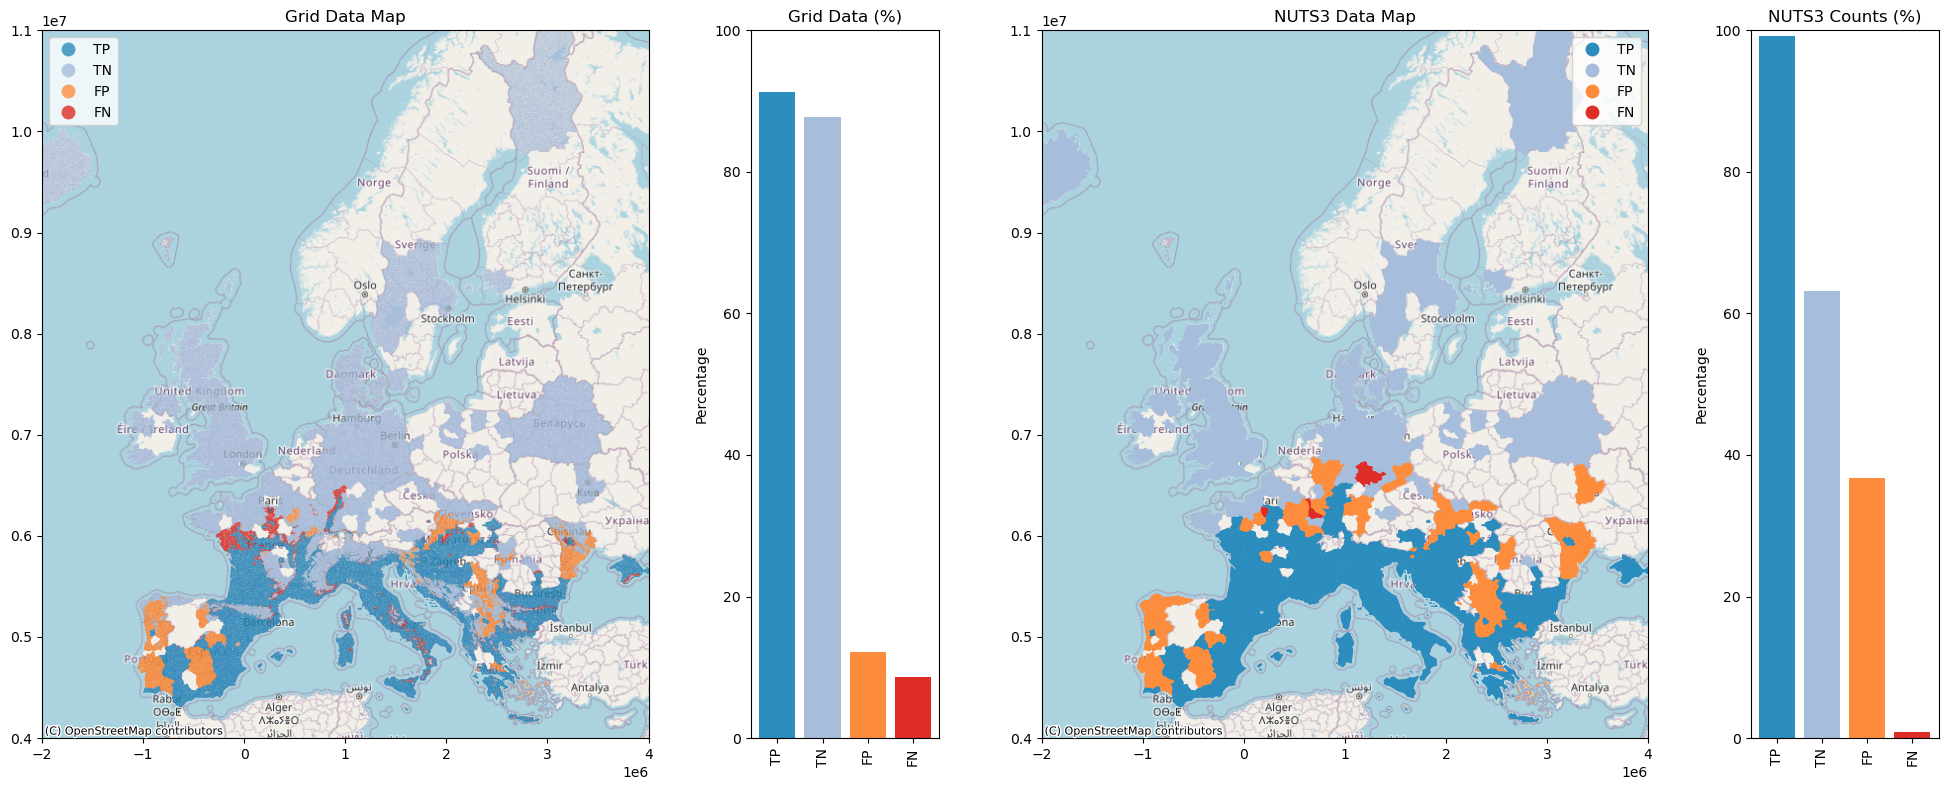

1
(-3068104.315626111, 4418780.803917829)
(3708047.3485630746, 13151603.917110967)
(-2000000.0, 4000000.0)
(4000000.0, 11000000.0)


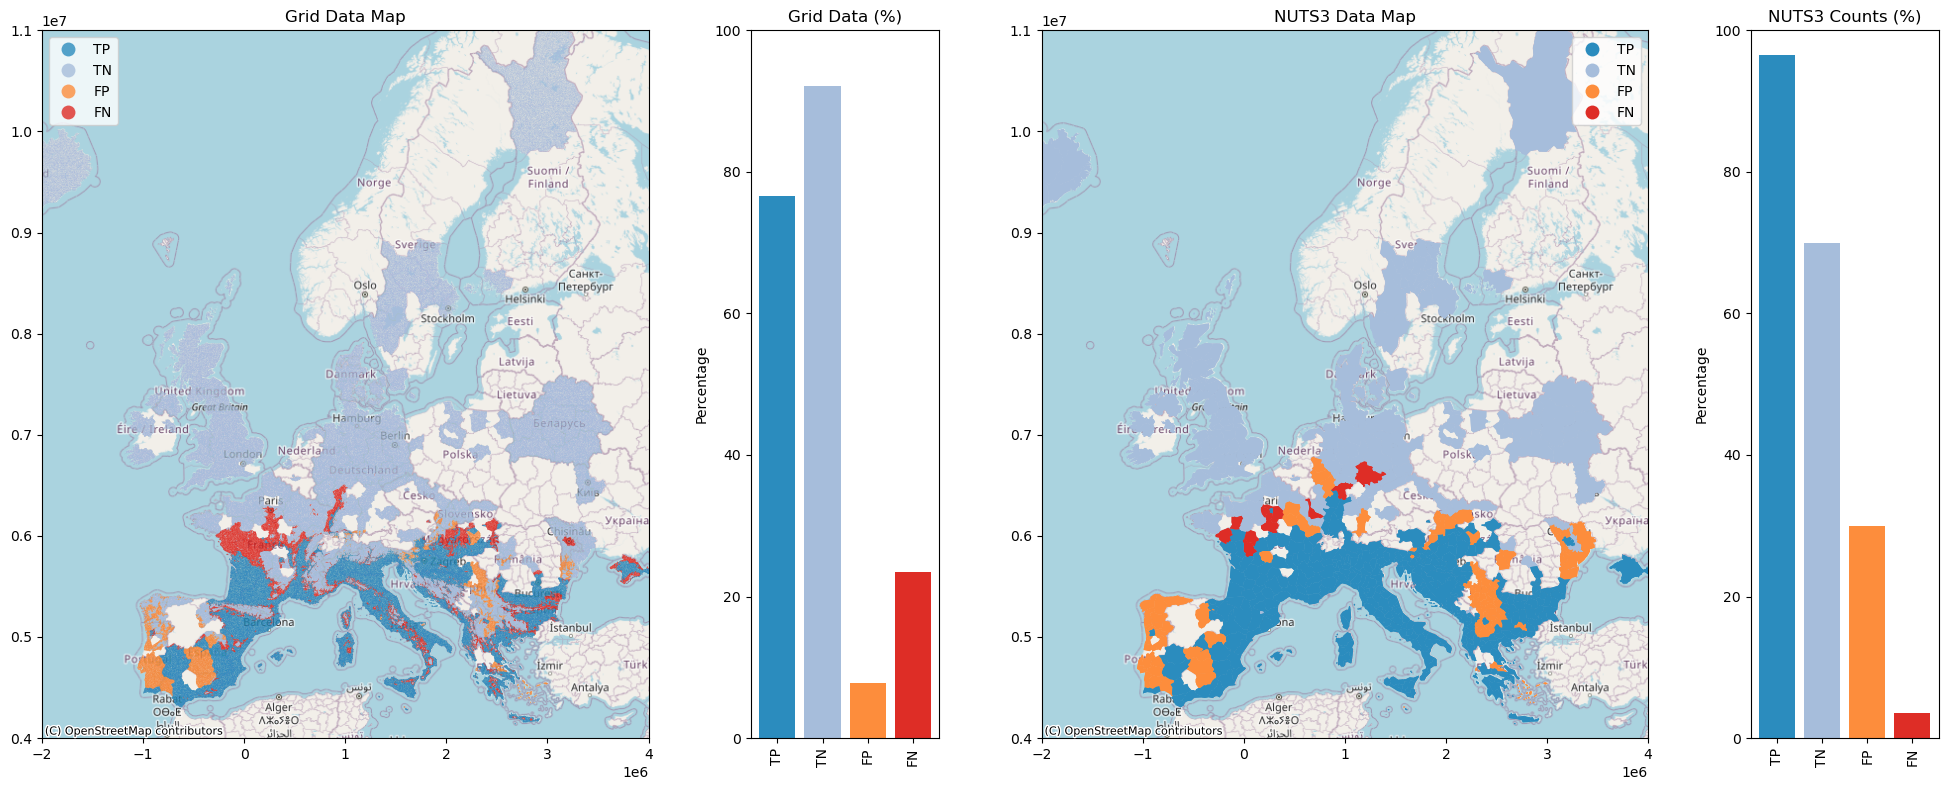

2
(-3070052.4067149945, 4418873.570160157)
(3709060.0108139873, 13155194.195017159)
(-2000000.0, 4000000.0)
(4000000.0, 11000000.0)


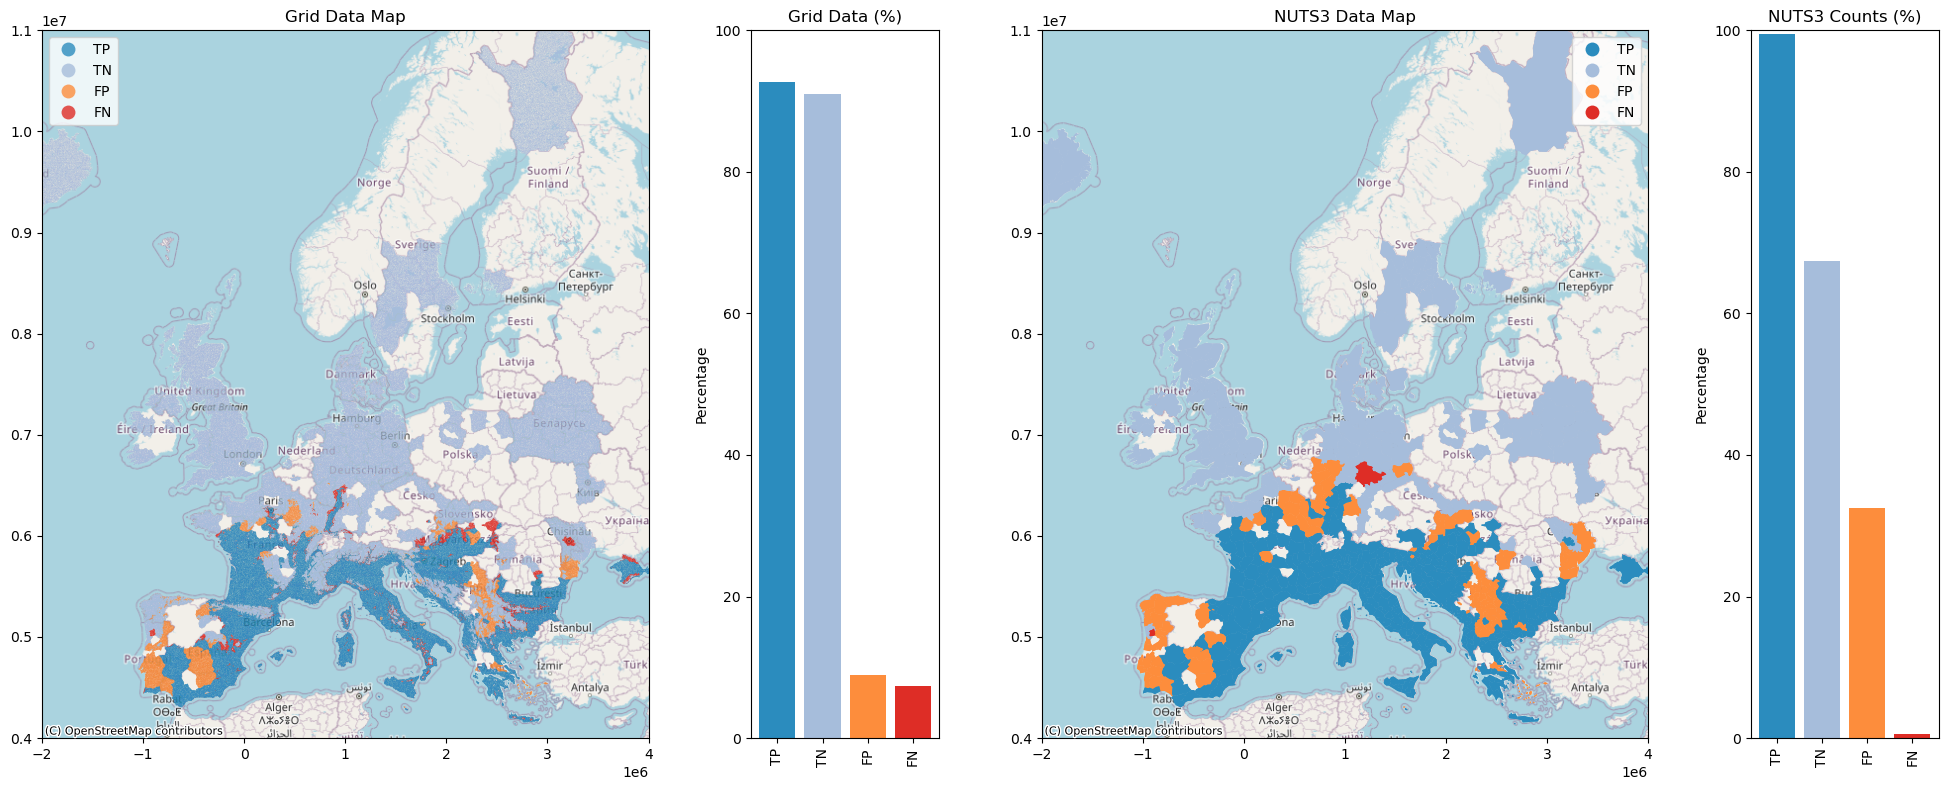

3
(-3066156.2245372306, 4418688.037675502)
(3710420.104403098, 13151490.928737633)
(-2000000.0, 4000000.0)
(4000000.0, 11000000.0)


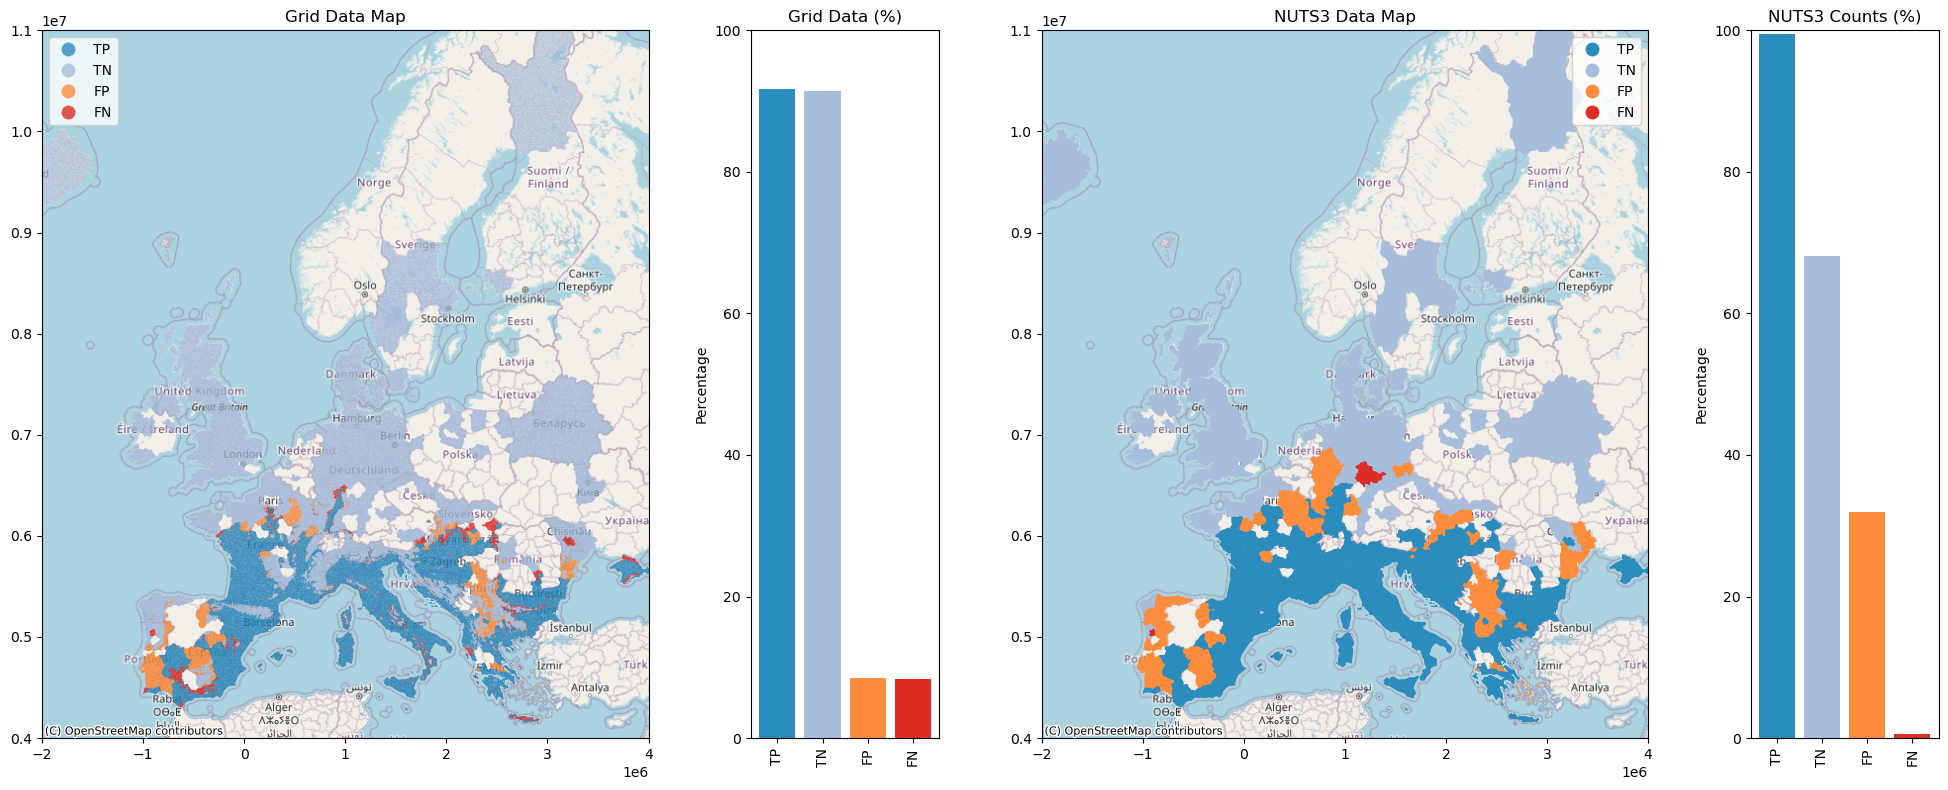

4
(-3069078.361170551, 4418827.187038993)
(3709060.0108139873, 13155194.195017159)
(-2000000.0, 4000000.0)
(4000000.0, 11000000.0)


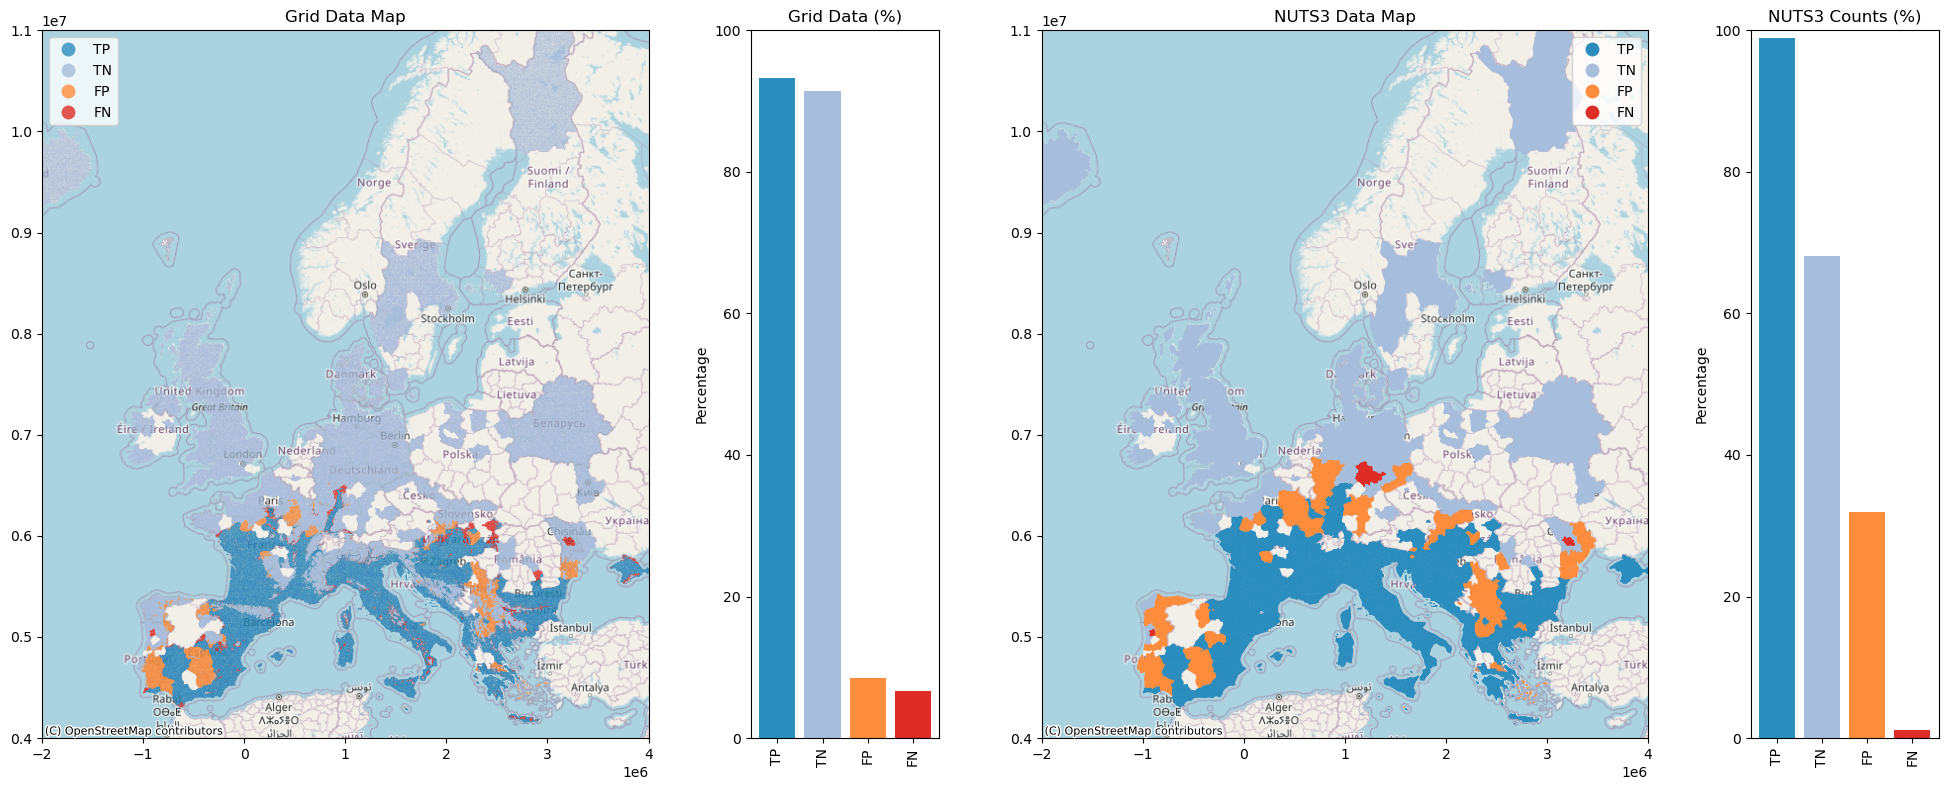

5
(-3068011.5493837832, 4416832.712828948)
(3709060.0108139873, 13155194.195017159)
(-2000000.0, 4000000.0)
(4000000.0, 11000000.0)


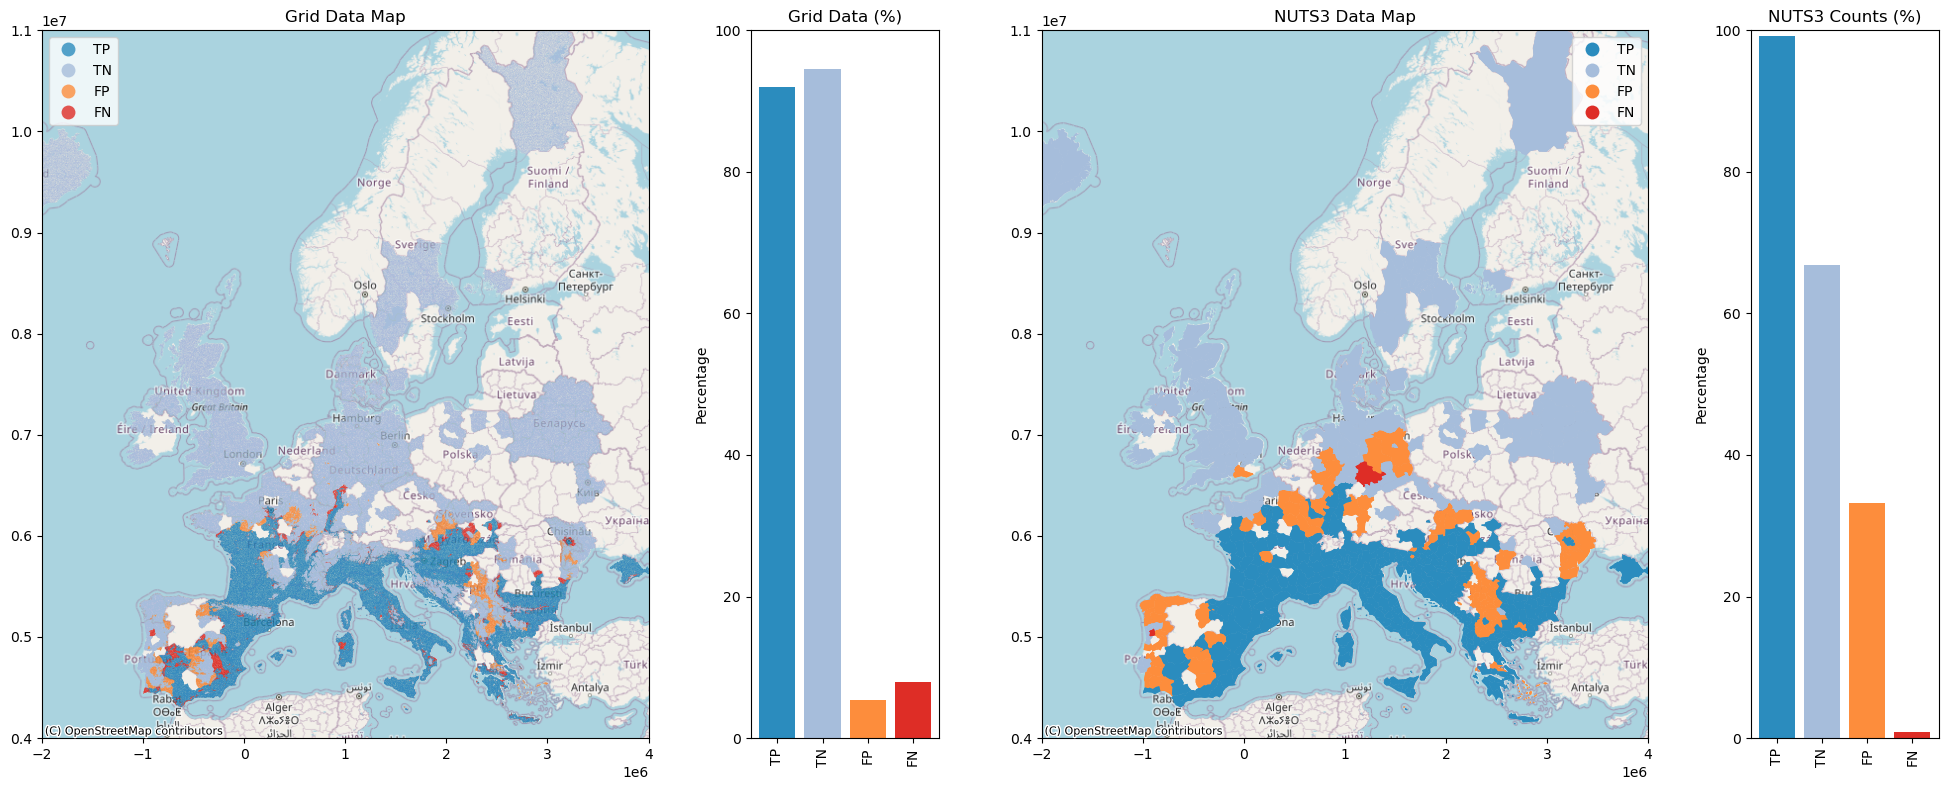

6
(-3068104.315626111, 4418780.803917829)
(3710420.104403098, 13151490.928737633)
(-2000000.0, 4000000.0)
(4000000.0, 11000000.0)


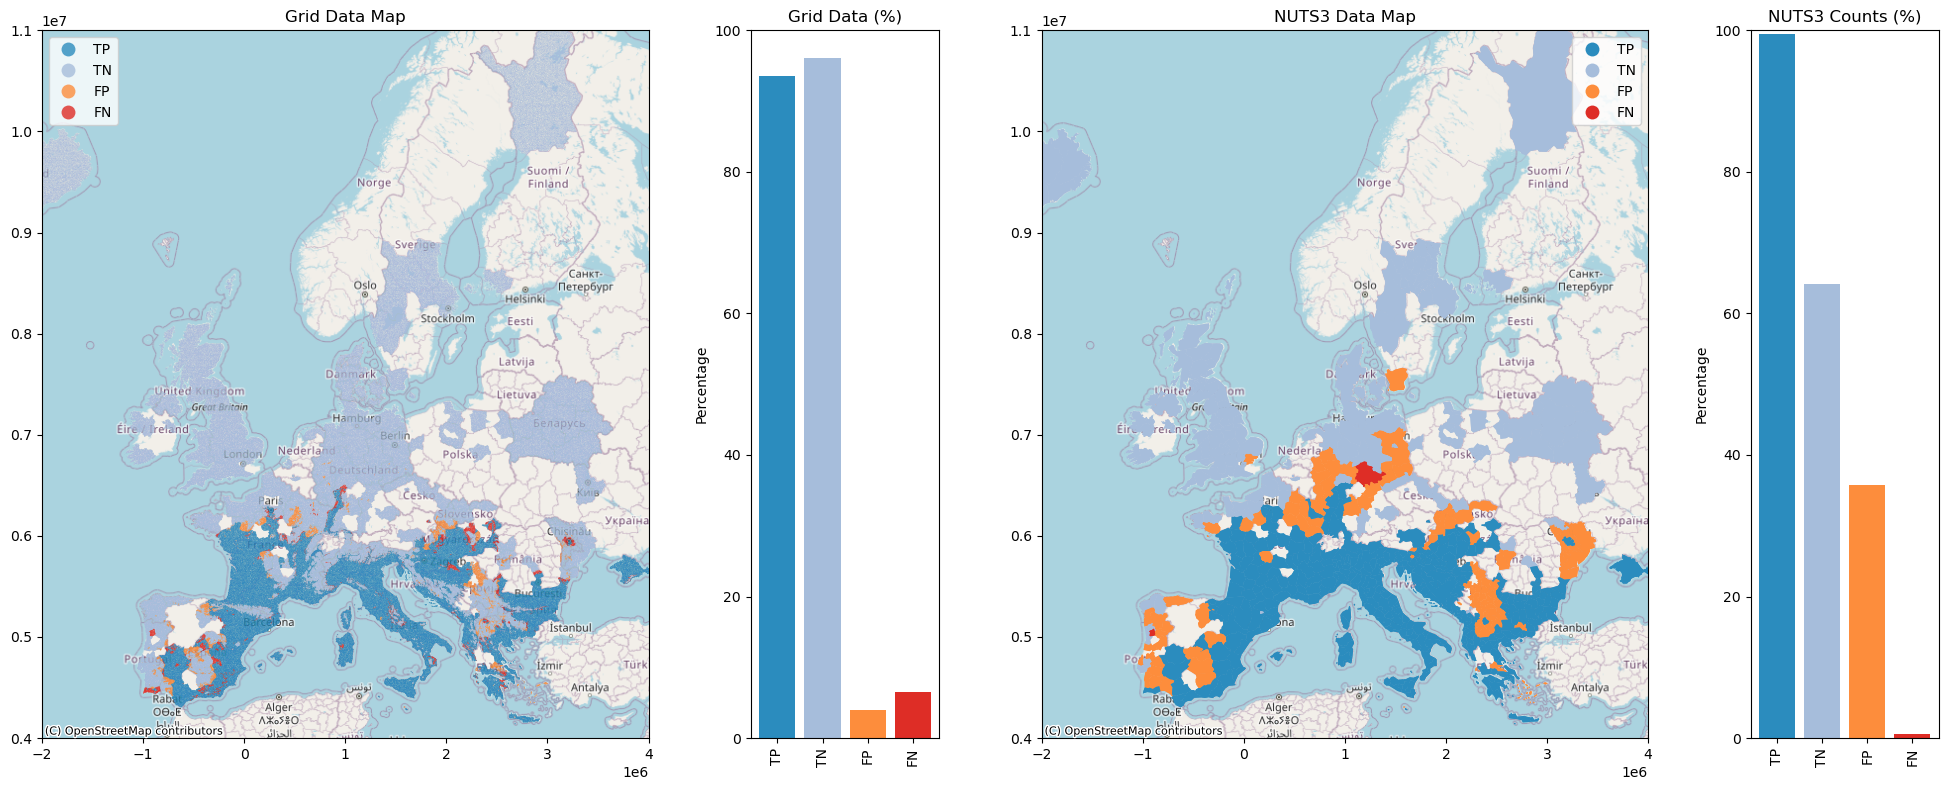

7
(-3067083.886960507, 4417760.3752522245)
(3708047.3485630746, 13151603.917110967)
(-2000000.0, 4000000.0)
(4000000.0, 11000000.0)


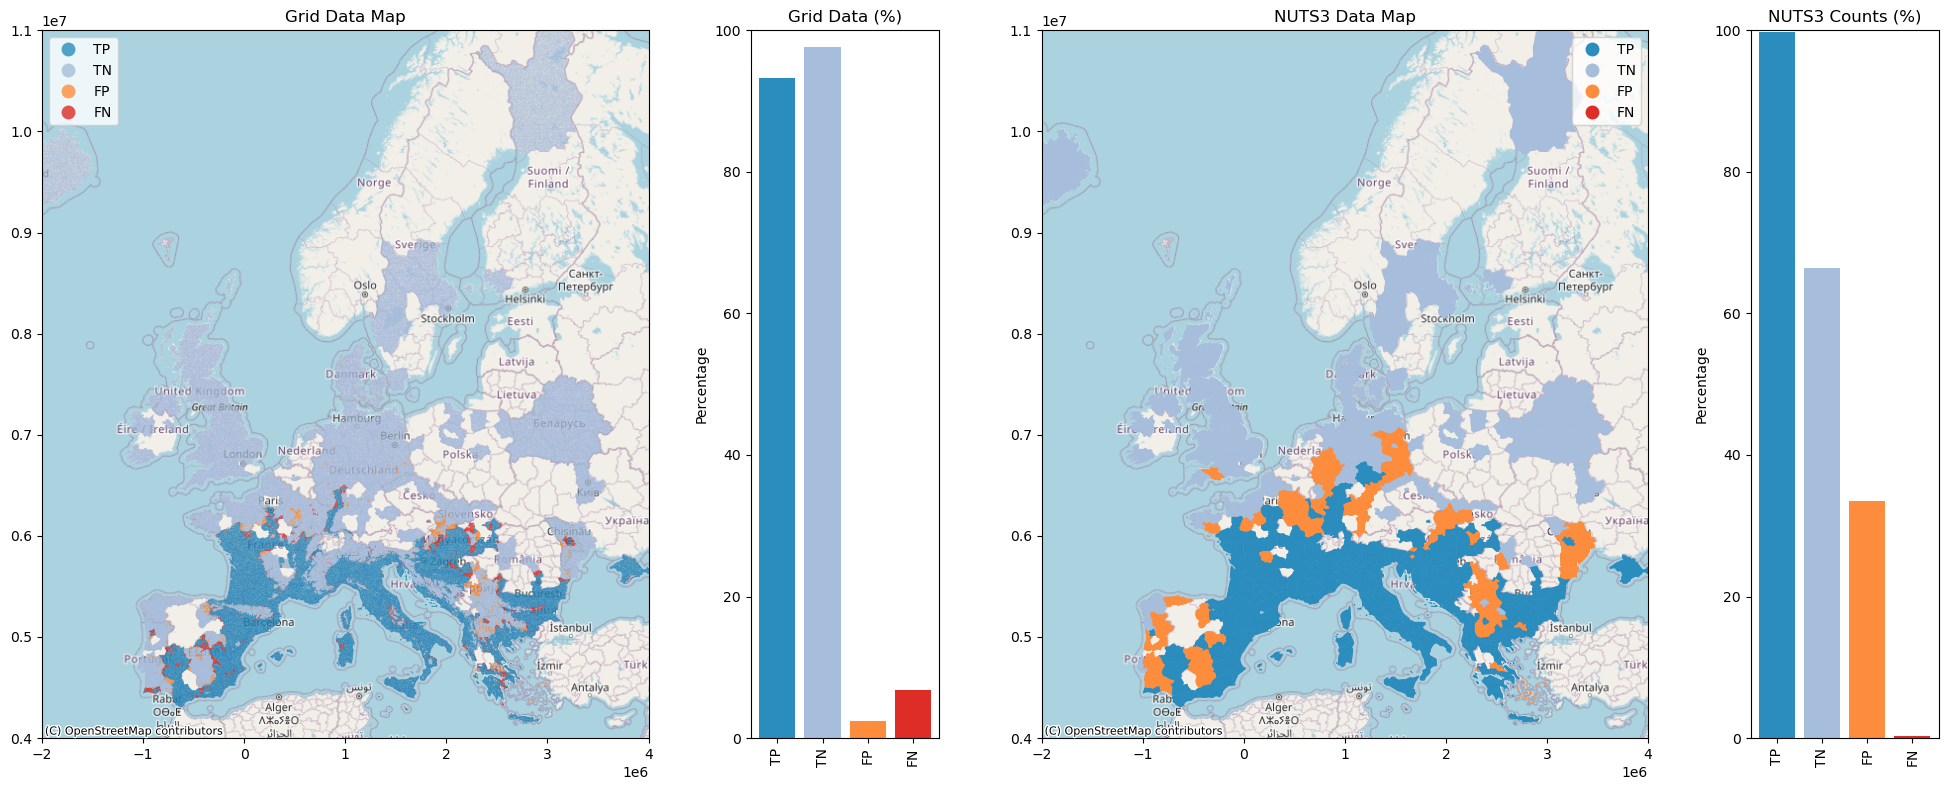

8
(-3067130.2700816705, 4418734.420796665)
(3708047.3485630746, 13151603.917110967)
(-2000000.0, 4000000.0)
(4000000.0, 11000000.0)


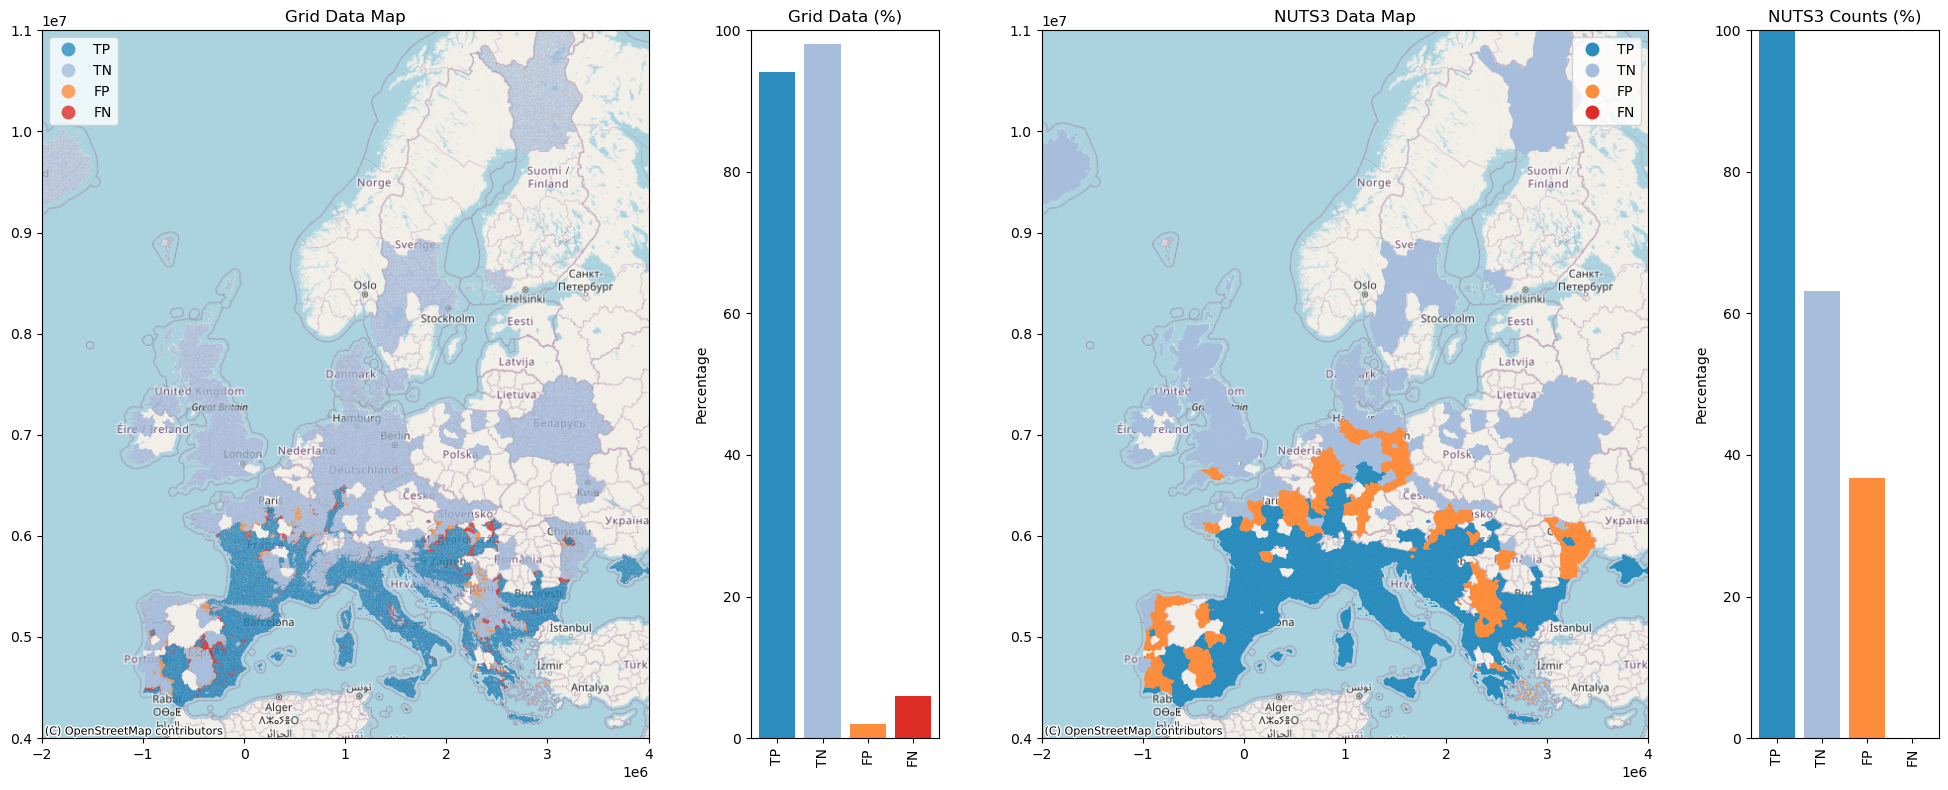

9
(-3068057.932504947, 4417806.758373389)
(3709233.6664918987, 13151547.425781023)
(-2000000.0, 4000000.0)
(4000000.0, 11000000.0)


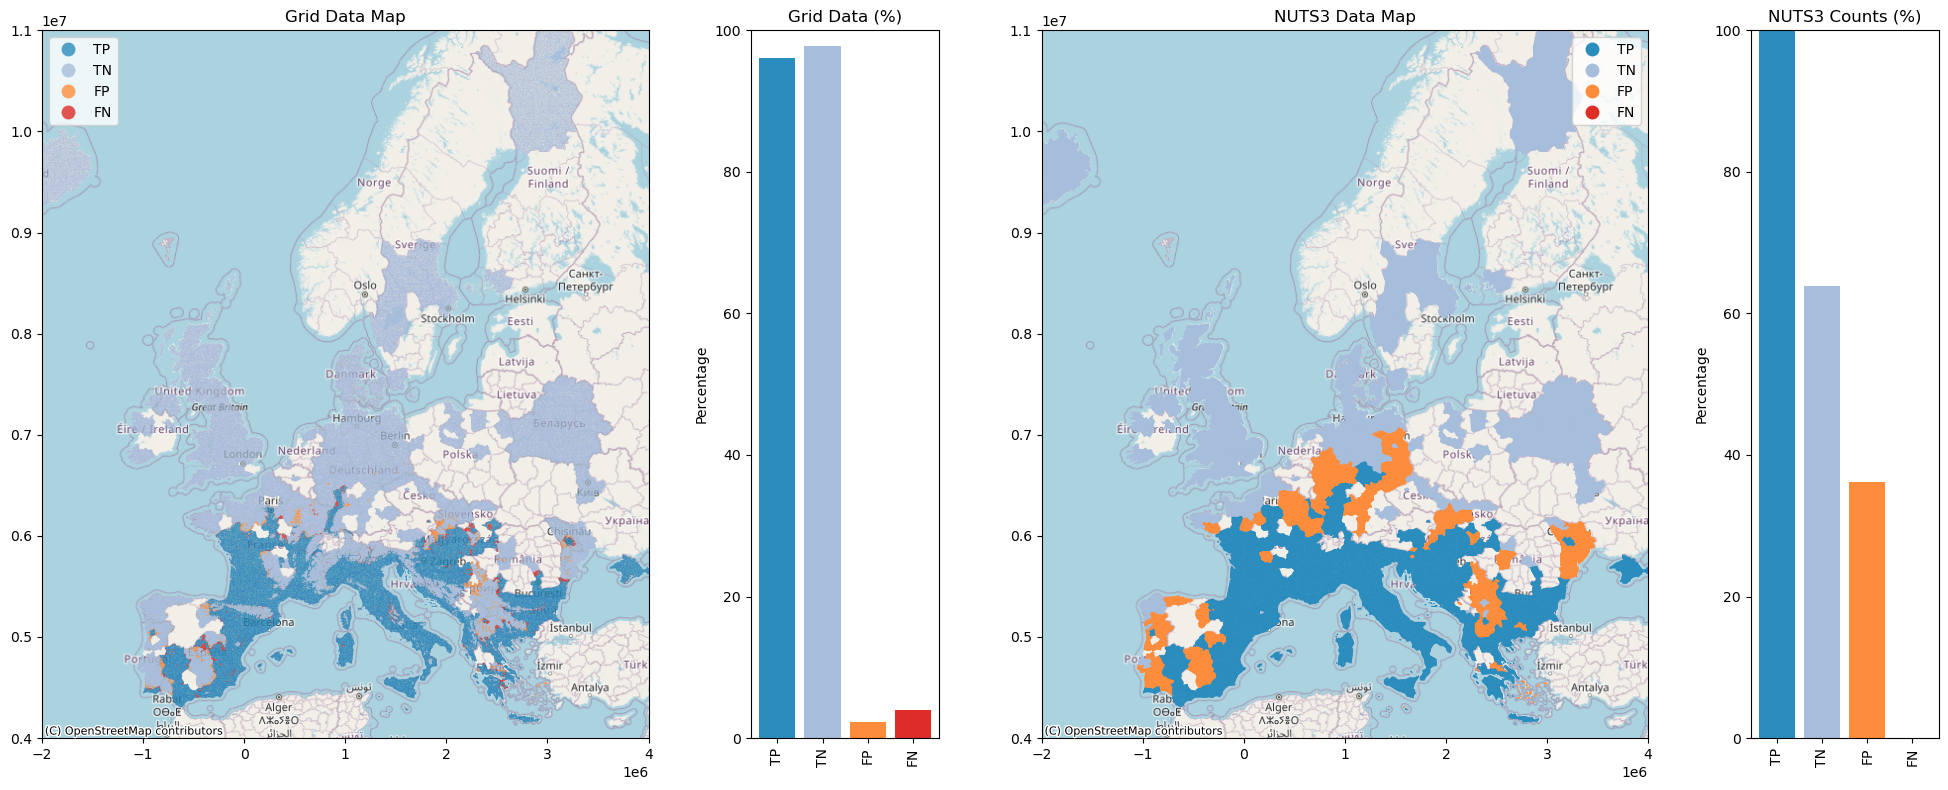

In [ ]:
import matplotlib.pyplot as plt

all_df_res = []
def pred_str(true, pred):
    return 'TP' if true == 1 and pred == 1 else 'TN' if true == 0 and pred == 0 else 'FN' if true == 1 and pred == 0 else 'FP'

for model_ in res_df.iterrows():
    i_net = model_[0]
    model_ = model_[1]
    print(i_net)
    #net_ = MosquitoNet(4, hidden_layers = model_["hidden_layers"])
    #net_.load_state_dict(model_["model"][0])
    net_ = model_["model"][0]
    df_temp = df_Presence_Absence[["Presence_Absence", "geometry", "NUTS3_Code"]].copy()
    if model_["type"] == "estim_risk":
        df_temp["predicted_estim_risk"] = compute_suitability_index(net_, test_loader_order_not).numpy()
    else:
        df_temp["predicted_estim_risk"] = compute_suitability_index(net_, test_loader_order).numpy()
    df_temp["predicted"] = df_temp["predicted_estim_risk"] > 0.5
    df_temp["results"] = df_temp.apply(lambda x: pred_str(x["Presence_Absence"], x["predicted"]), axis=1)
    fig, ax_ = plot_results(df_temp, gdf_NUTS3, num_samples=2000000)
    fig.savefig(f"res_plots/res_net_{i_net}_type_{model_['type']}_num_params_{model_['num_params']}.png", dpi=400)
    all_df_res.append(df_temp)


# Code for plotting aggregate results in function of number of params

In [ ]:
res_df_four[""]

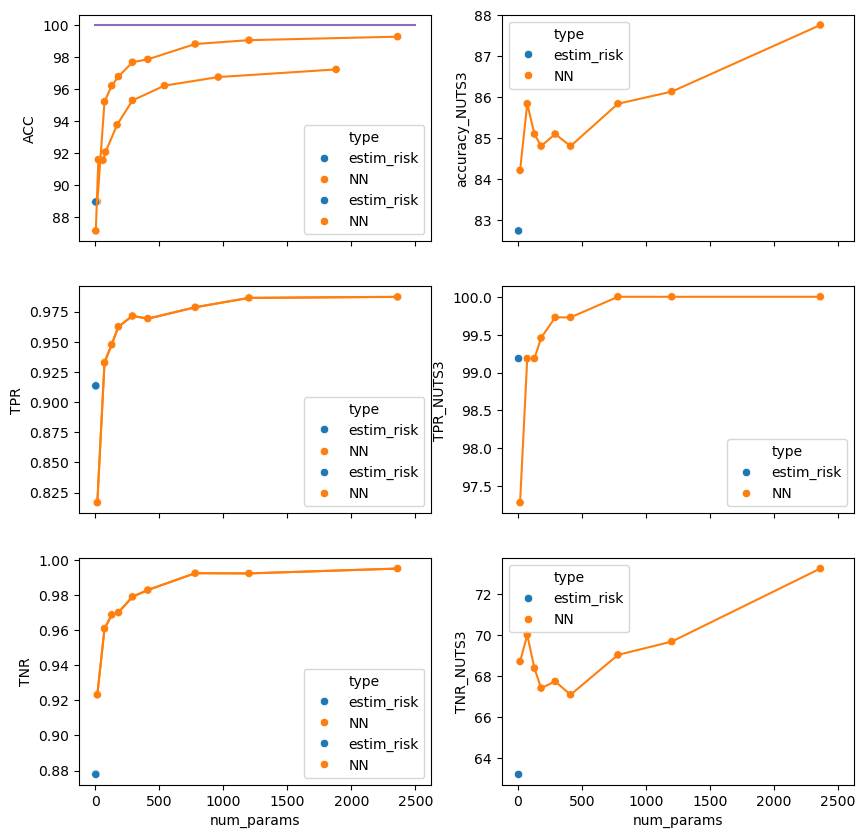

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


fig, axes = plt.subplots(3, 2, figsize=(10,10), sharex=True)

sns.lineplot(data=res_df, x='num_params', y='ACC', hue='type', ax = axes[0, 0], legend=False)
sns.scatterplot(data=res_df, x='num_params', y='ACC', hue='type', ax = axes[0, 0])

sns.lineplot(data=res_df_four, x='num_params', y='ACC', hue='type', ax = axes[0, 0], legend=False, color="green")
sns.scatterplot(data=res_df_four, x='num_params', y='ACC', hue='type', ax = axes[0, 0])

axes[0, 0].plot([0, 2500],[100, 100])

sns.lineplot(data=res_df, x='num_params', y='accuracy_NUTS3', hue='type', ax = axes[0, 1], legend=False)
sns.scatterplot(data=res_df, x='num_params', y='accuracy_NUTS3', hue='type', ax = axes[0, 1])

sns.lineplot(data=res_df, x='num_params', y='TPR_NUTS3', hue='type', ax = axes[1, 1], legend=False)
sns.scatterplot(data=res_df, x='num_params', y='TPR_NUTS3', hue='type', ax = axes[1, 1])

sns.lineplot(data=res_df, x='num_params', y='TNR_NUTS3', hue='type', ax = axes[2, 1], legend=False)
sns.scatterplot(data=res_df, x='num_params', y='TNR_NUTS3', hue='type', ax = axes[2, 1])

sns.lineplot(data=res_df, x='num_params', y='TPR', hue='type', ax = axes[1, 0], legend=False)
sns.scatterplot(data=res_df, x='num_params', y='TPR', hue='type', ax = axes[1, 0])

sns.lineplot(data=res_df, x='num_params', y='TNR', hue='type', ax = axes[2, 0], legend=False)
sns.scatterplot(data=res_df, x='num_params', y='TNR', hue='type', ax = axes[2, 0])

sns.lineplot(data=res_df, x='num_params', y='TPR_test', hue='type', ax = axes[1, 0], legend=False)
sns.scatterplot(data=res_df, x='num_params', y='TPR_test', hue='type', ax = axes[1, 0])

sns.lineplot(data=res_df, x='num_params', y='TNR_test', hue='type', ax = axes[2, 0], legend=False)
sns.scatterplot(data=res_df, x='num_params', y='TNR_test', hue='type', ax = axes[2, 0])

fig.savefig("perfomance_vs_num_params.png")

In [ ]:
res_df.columns

Index(['accuracy_NUTS3', 'TPR_NUTS3', 'FNR_NUTS3', 'FPR_NUTS3', 'TNR_NUTS3',
       'ACC', 'TPR', 'TNR', 'FPR', 'FNR', 'ACC_test', 'TPR_test', 'TNR_test',
       'FPR_test', 'FNR_test', 'type', 'hidden_layers', 'num_params', 'bias',
       'num_epochs', 'test_ratio', 'learning_rate', 'random_seed', 'model'],
      dtype='object')